## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import shap

%matplotlib inline

## Tabela

In [3]:
save_folder_path_trusted = 'dados/raw_trusted'
save_folder_path_refined = 'dados/refined'

In [5]:
# Ler tabela analítica
dim_tickers = pd.read_parquet(f"{save_folder_path_refined}/dim_tickers.parquet", engine = 'pyarrow')
tb_analitica = pd.read_parquet(f"{save_folder_path_refined}/tb_analitica_ABEV3.parquet", engine = 'pyarrow')

In [6]:
print(f"{tb_analitica.shape[0]:_}")

2_469


In [20]:
tb_analitica.head()

,ticker,date,weekday,close,high,low,open,volume,close_dolar,close_ibovespa,close_sp_500,selic,ipca,ma20,ma50,bb_upper,bb_lower,rsi_wilder,macd,macd_signal,weekday_sin,weekday_cos,month_sin,month_cos
9,ABEV3,2016-07-01,Friday,12.81,12.81,12.66,12.72,22773000.00,3.21,52233.00,2102.95,0.05,0.52,NaN,NaN,NaN,NaN,NaN,0.00,0.00,-0.95,0.31,0.00,-1.00
10,ABEV3,2016-07-04,Monday,12.70,12.86,12.65,12.81,6702100.00,3.23,52569.00,2102.95,0.05,0.52,NaN,NaN,NaN,NaN,0.00,-0.01,-0.00,0.00,1.00,0.00,-1.00
11,ABEV3,2016-07-05,Tuesday,12.86,12.88,12.64,12.64,13405900.00,3.29,51842.00,2088.55,0.05,0.52,NaN,NaN,NaN,NaN,9.96,-0.00,-0.00,0.95,0.31,0.00,-1.00
12,ABEV3,2016-07-06,Wednesday,12.78,12.85,12.64,12.82,11263900.00,3.30,51902.00,2099.73,0.05,0.52,NaN,NaN,NaN,NaN,9.47,-0.00,-0.00,0.59,-0.81,0.00,-1.00
13,ABEV3,2016-07-07,Thursday,12.73,12.86,12.67,12.78,8916400.00,3.33,52015.00,2097.90,0.05,0.52,NaN,NaN,NaN,NaN,9.12,-0.01,-0.00,-0.59,-0.81,0.00,-1.00


## Métricas ao longo do tempo

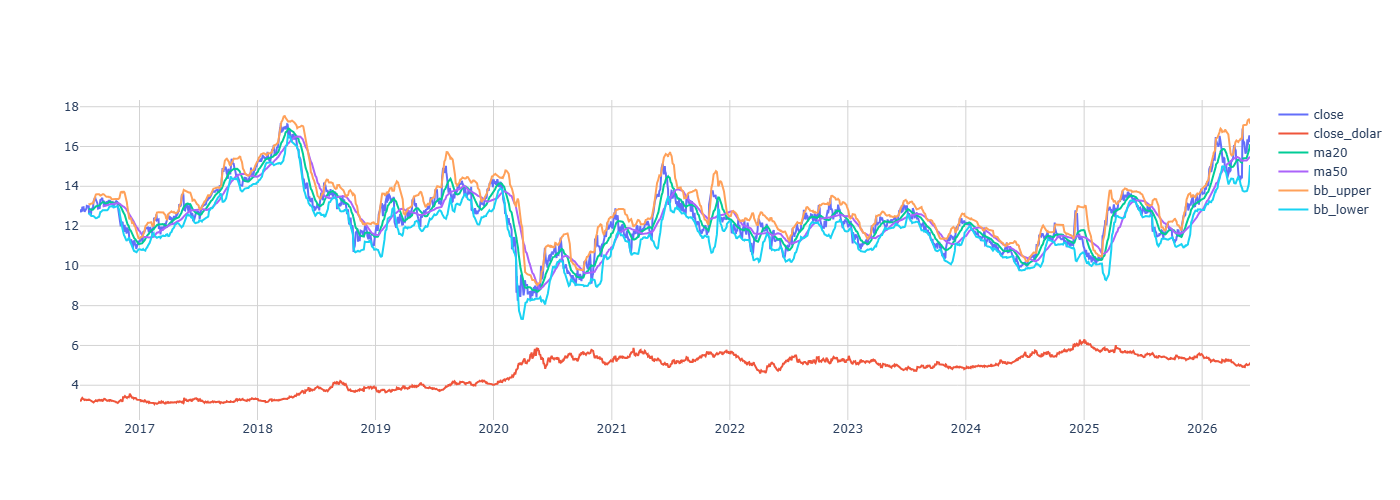

In [25]:
import plotly.graph_objects as go

fig = go.Figure()

for coluna in ['close', 'close_dolar', 'ma20', 'ma50', 'bb_upper', 'bb_lower']:
    fig.add_trace(go.Line(x = tb_analitica['date'], y = tb_analitica[coluna], name = coluna))

fig.update_layout(plot_bgcolor = 'white', width = 1400)

fig.update_xaxes(
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=1
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=1
)
fig.show(renderer="png")

In [21]:
colunas_idx = ['ticker', 'date', 'weekday']
vars = [c for c in tb_analitica.columns if c not in colunas_idx]

len(vars)

21

In [21]:
def gerar_graficos(vars):
    for coluna in vars:
        max = tb_analitica[coluna].max() * 1.1
        fig = px.line(tb_analitica, x = 'date', y = coluna)
        fig.update_layout(plot_bgcolor = 'white', title = coluna, height = 300, width = 1400)

        fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
        fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
        fig.show(renderer="png")

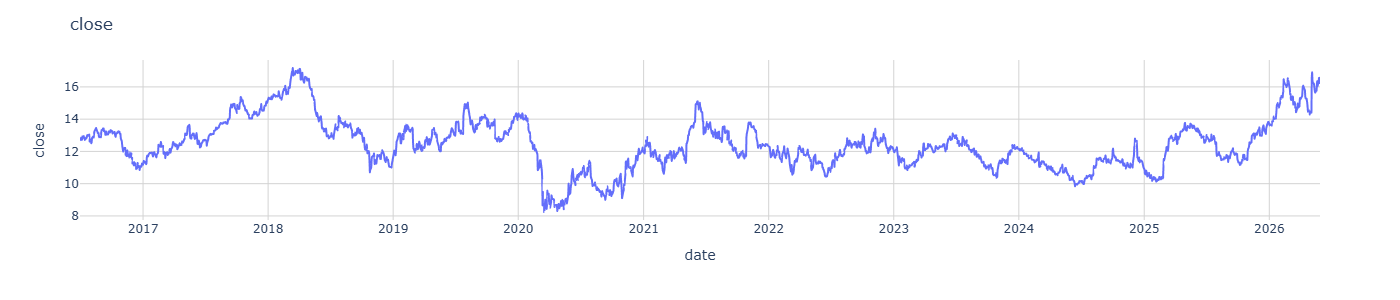

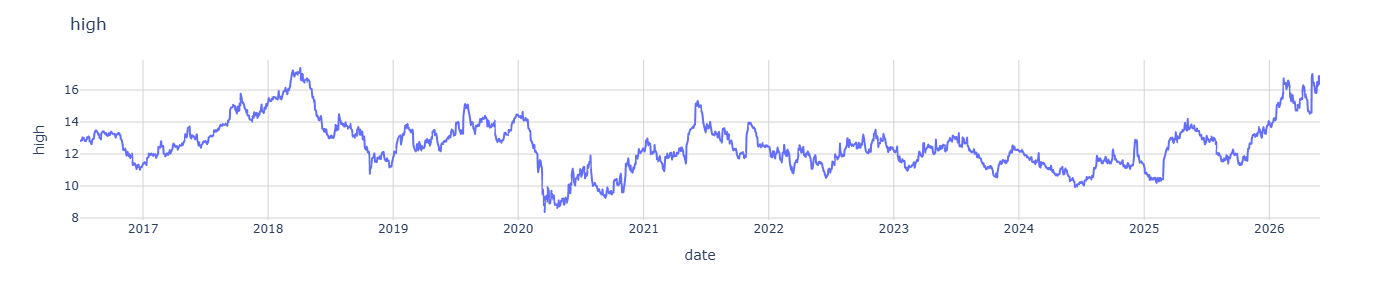

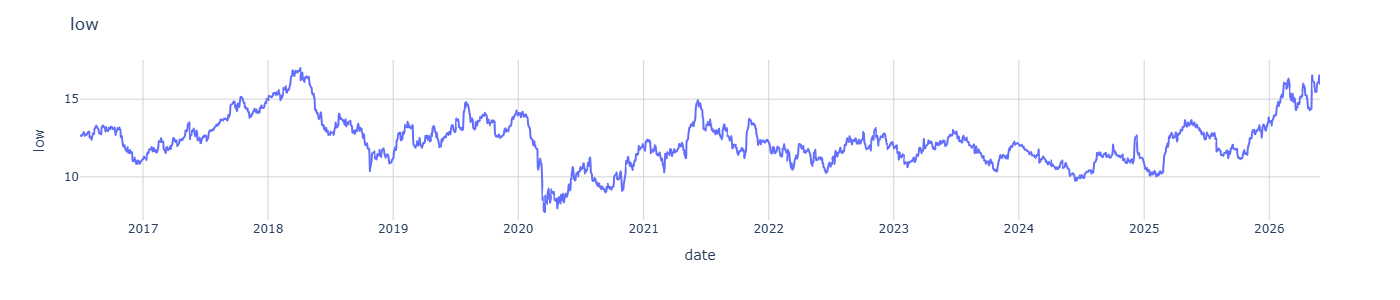

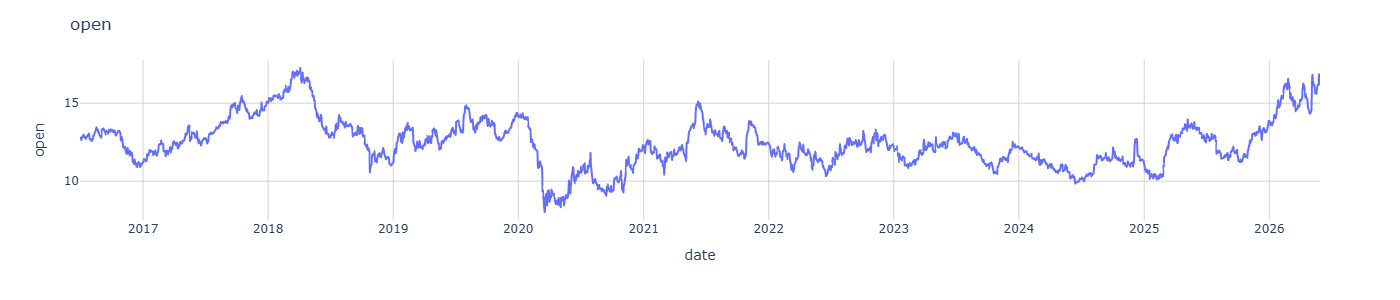

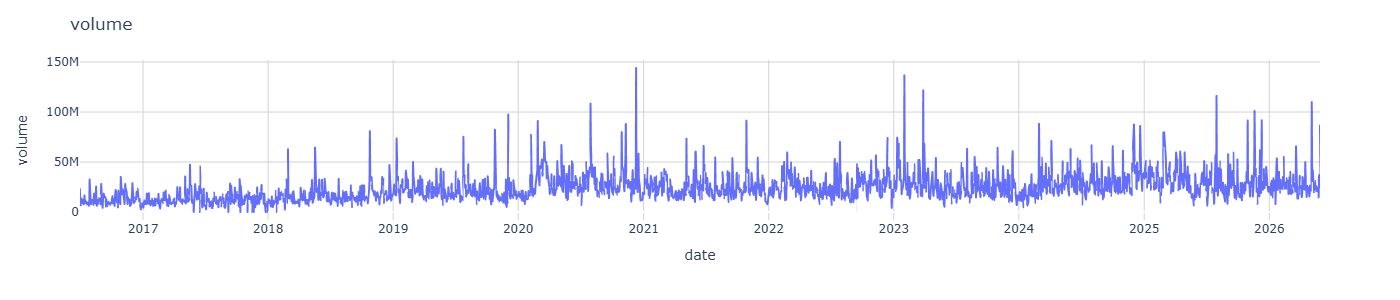

In [22]:
gerar_graficos(vars = ['close', 'high', 'low', 'open', 'volume'])

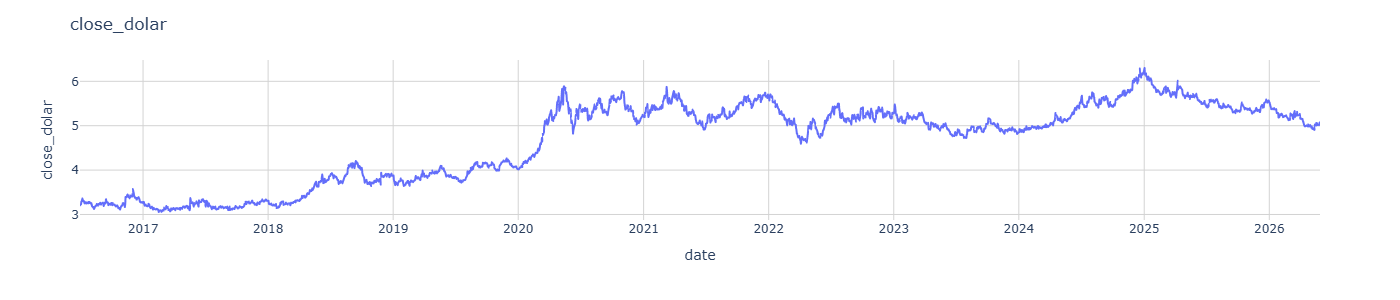

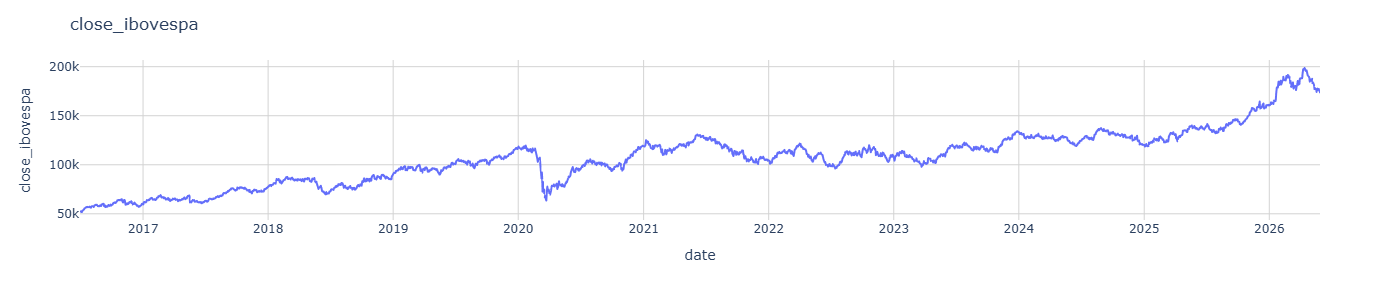

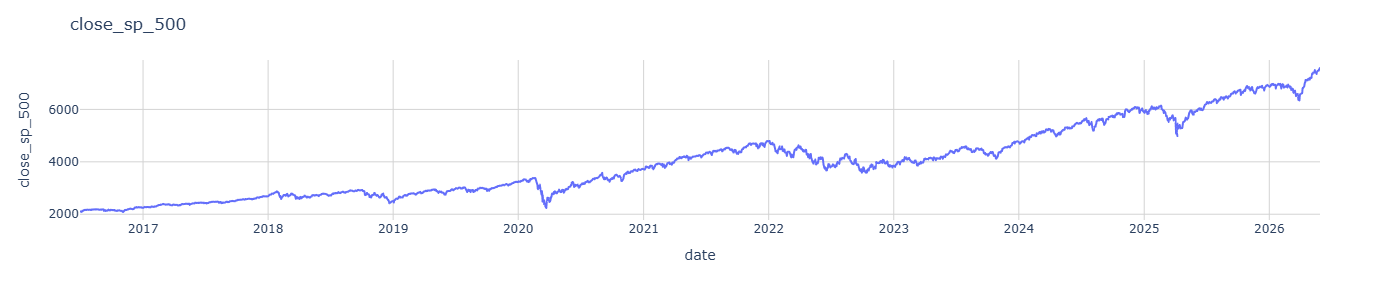

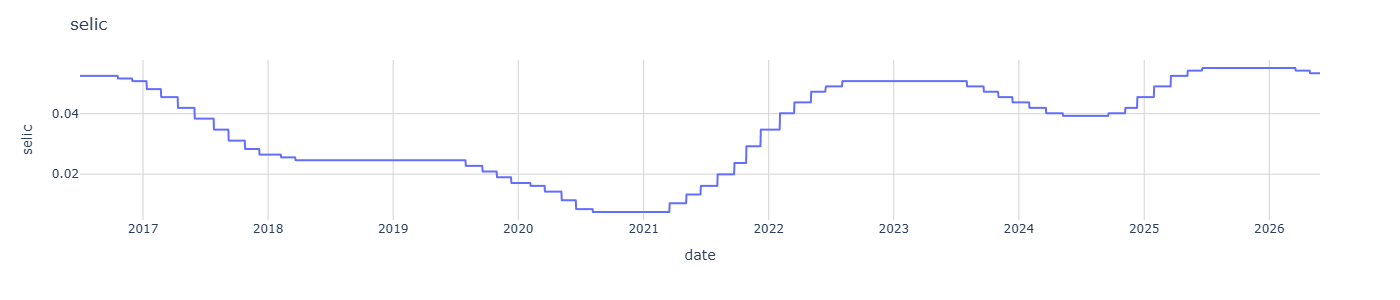

In [ ]:
gerar_graficos(vars = ['close_dolar', 'close_ibovespa', 'close_sp_500', 'selic', 'ipca'])

In [ ]:
gerar_graficos(vars = ['rsi_wilder', 'macd', 'macd_signal'])

## Matriz de correlação

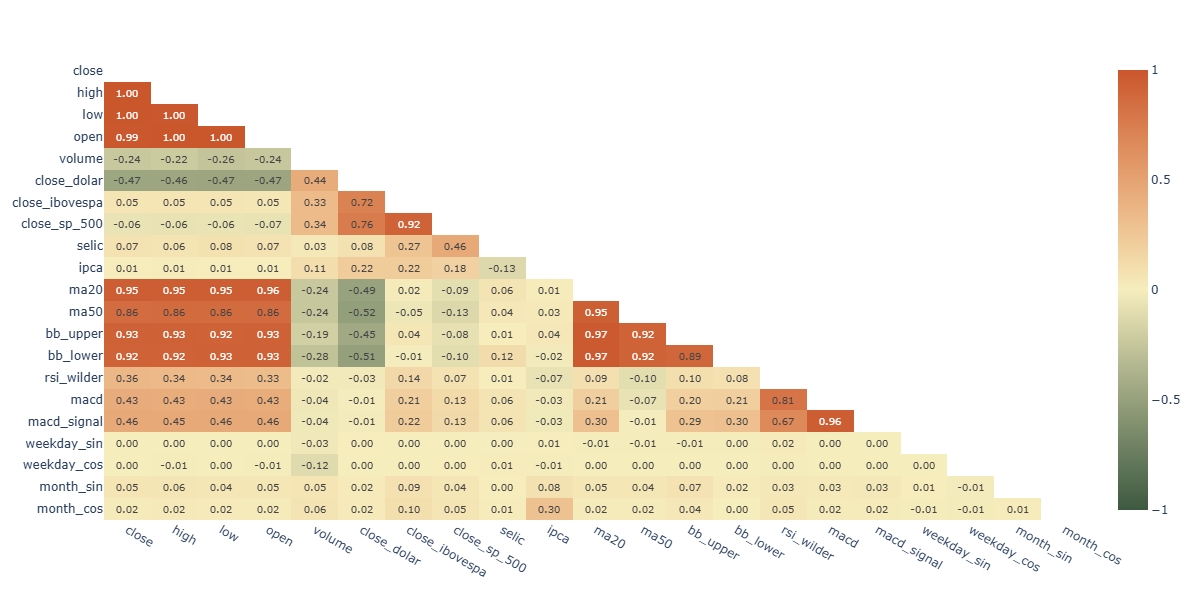

In [7]:
# 1. Compute the correlation matrix
corr_matrix = tb_analitica.corr(numeric_only=True)

# 2. Create a mask to hide the upper triangle (replace with np.nan)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_masked = corr_matrix.mask(mask)

# 3. Plot the triangular heatmap
fig = px.imshow(
    corr_masked,
    text_auto=".2f", # Adds numeric values to the cells
    color_continuous_scale="fall",
    zmin=-1, zmax=1,
    aspect='auto'
)

fig.update_layout(plot_bgcolor = 'white', height = 600, width = 1200)
fig.update_traces(textfont = dict(size = 10))

fig.show(renderer="png")

## Histograma

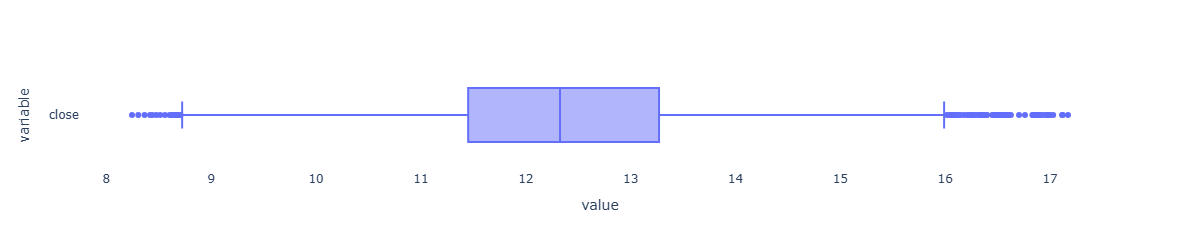

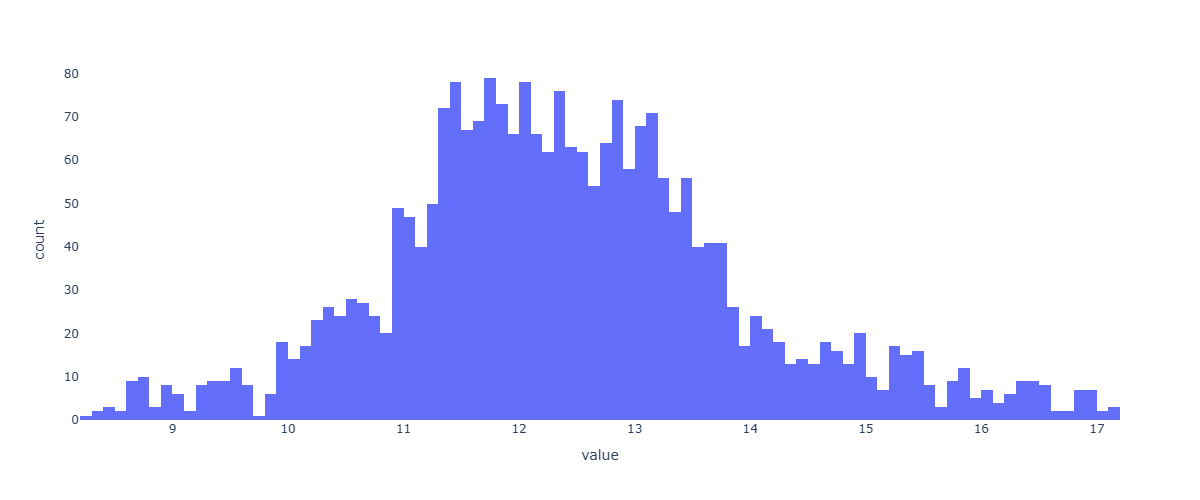

In [10]:
fig = px.box(tb_analitica, x = ['close'])
fig.update_layout(plot_bgcolor = 'white', showlegend = False, height = 250, width = 1200)
fig.show(renderer="png")

fig = px.histogram(tb_analitica, x = ['close'], nbins = 100)
fig.update_layout(plot_bgcolor = 'white', showlegend = False, width = 1200)
fig.show(renderer="png")

## Scatterplots

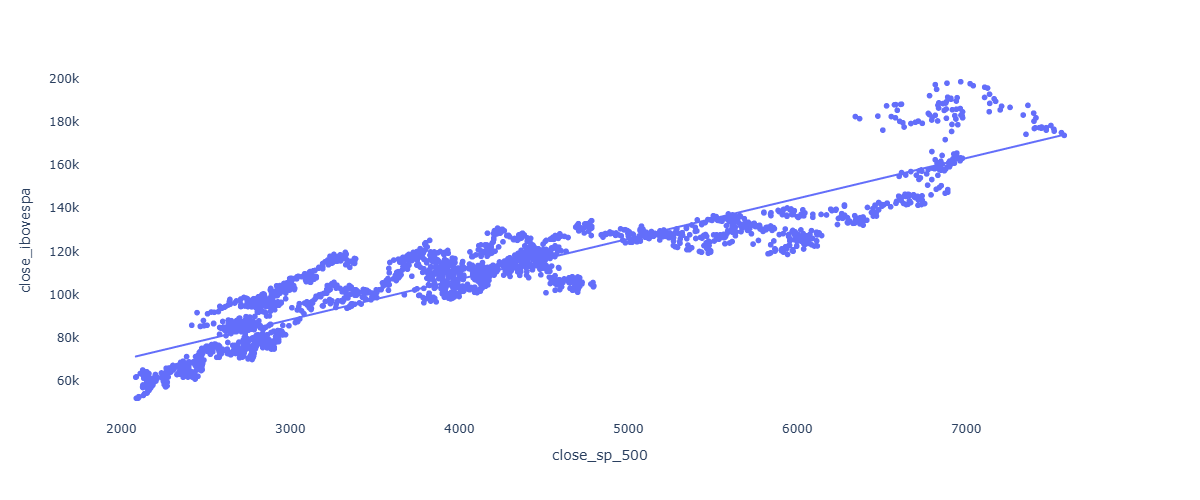

In [11]:
fig = px.scatter(tb_analitica, x = 'close_sp_500', y = 'close_ibovespa', trendline = 'ols')
fig.update_layout(plot_bgcolor = 'white', showlegend = False, width = 1200)
fig.show(renderer="png")

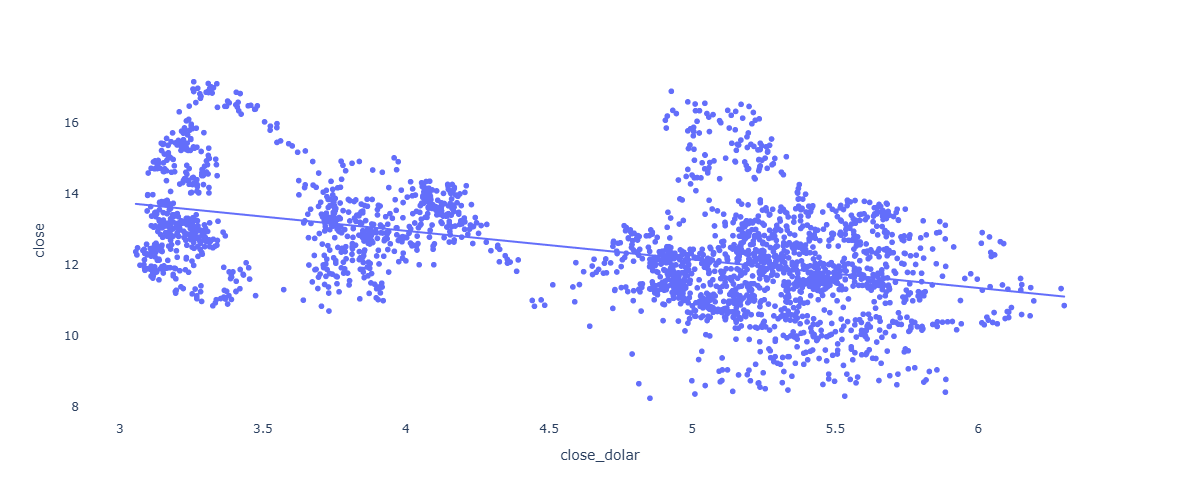

In [12]:
fig = px.scatter(tb_analitica, x = 'close_dolar', y = 'close', trendline = 'ols')
fig.update_layout(plot_bgcolor = 'white', showlegend = False, width = 1200)
fig.show(renderer="png")

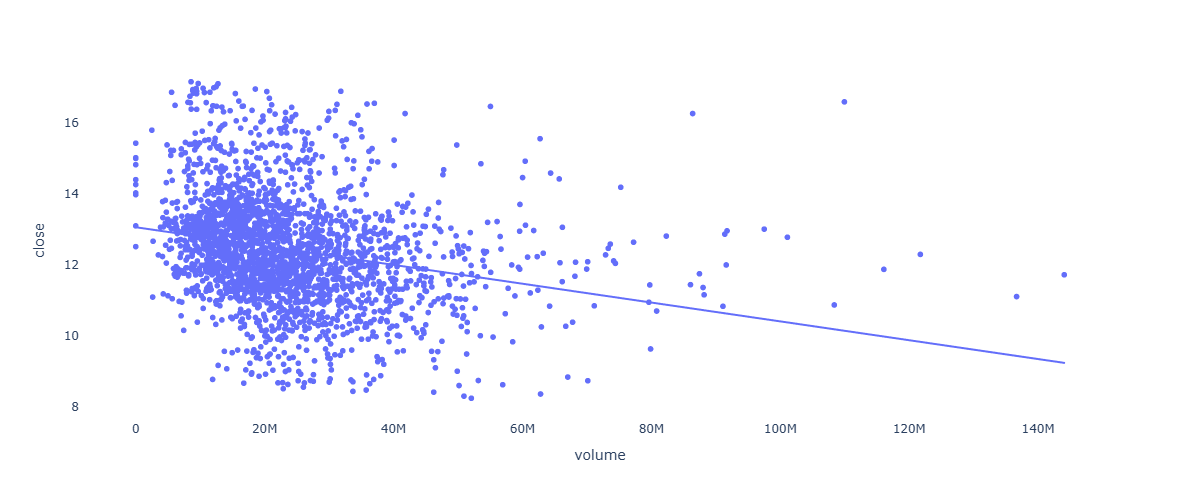

In [13]:
fig = px.scatter(tb_analitica, x = 'volume', y = 'close', trendline = 'ols')
fig.update_layout(plot_bgcolor = 'white', showlegend = False, width = 1200)
fig.show(renderer="png")

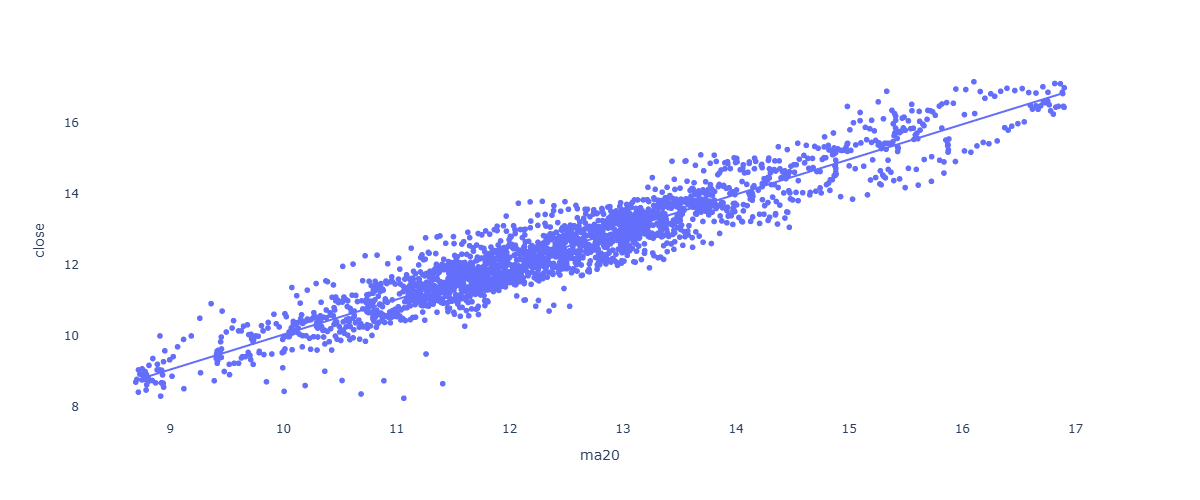

In [14]:
fig = px.scatter(tb_analitica, x = 'ma20', y = 'close', trendline = 'ols')
fig.update_layout(plot_bgcolor = 'white', showlegend = False, width = 1200)
fig.show(renderer="png")

## Autocorrelação

ESTATÍSTICAS DESCRITIVAS

Resumo estatístico da variável de fechamento.
Permite identificar faixa de valores, dispersão e possíveis valores extremos.

count   2469.00
mean      12.43
std        1.55
min        8.24
25%       11.45
50%       12.33
75%       13.27
max       17.17
Name: close, dtype: float64

TESTE DE DICKEY-FULLER AUMENTADO (ADF)

O teste ADF verifica se a série é estacionária.

Hipótese nula (H0): a série NÃO é estacionária.
Hipótese alternativa (H1): a série é estacionária.

Se p-value < 0.05:
    rejeita-se H0 e considera-se a série estacionária.

ADF Statistic : -2.8142
p-value       : 0.056272

Resultado: Série NÃO estacionária.

GRÁFICO DA SÉRIE TEMPORAL

Permite visualizar tendências, mudanças de regime e períodos de alta volatilidade.
Em séries de preços é esperado observar tendência ao longo do tempo.



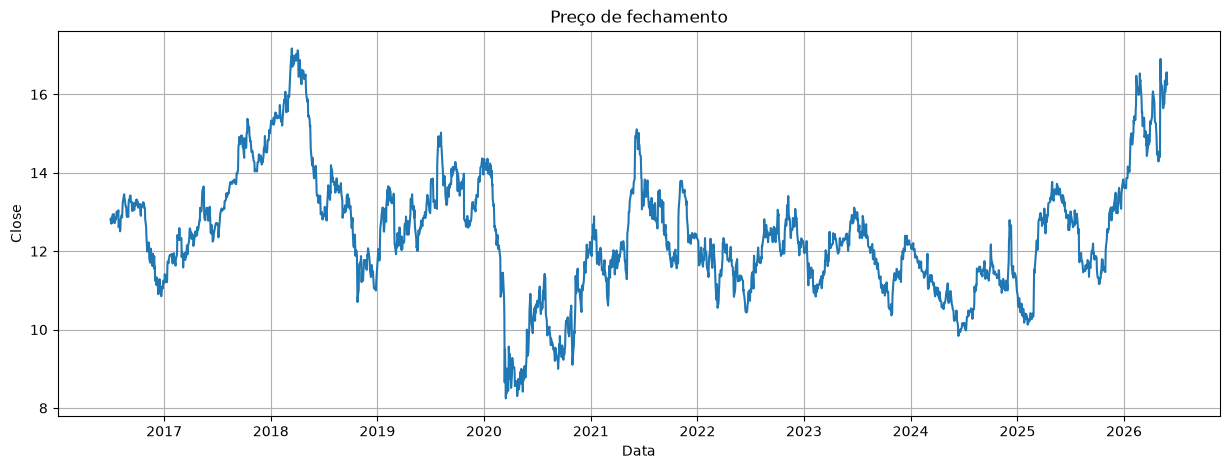


FUNÇÃO DE AUTOCORRELAÇÃO (ACF)

A ACF mede a correlação entre a série atual e seus valores passados.

Quanto mais lentamente as barras diminuem,
maior é a dependência temporal da série.

Barras fora da região azul representam correlações estatisticamente significativas.



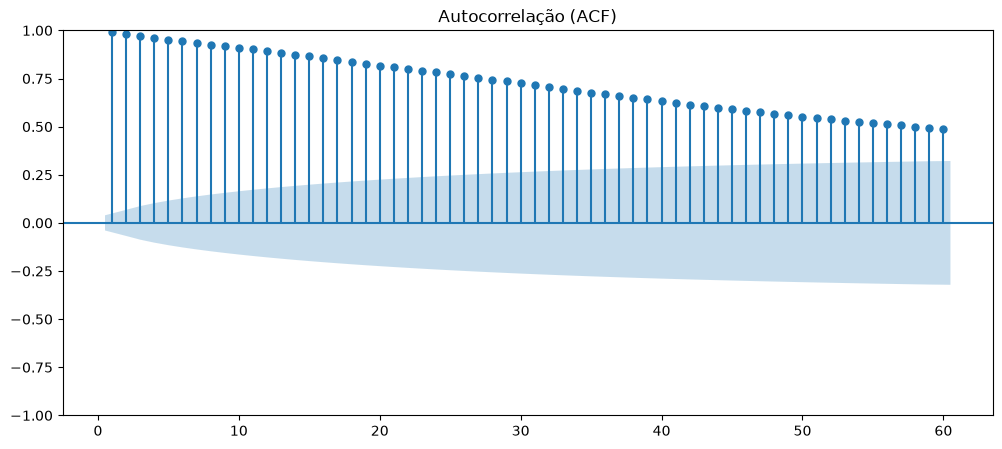


FUNÇÃO DE AUTOCORRELAÇÃO PARCIAL (PACF)

A PACF mede a correlação direta entre uma observação e cada defasagem,
eliminando o efeito das defasagens intermediárias.

Ela ajuda a identificar quais lags possuem influência direta sobre a série.



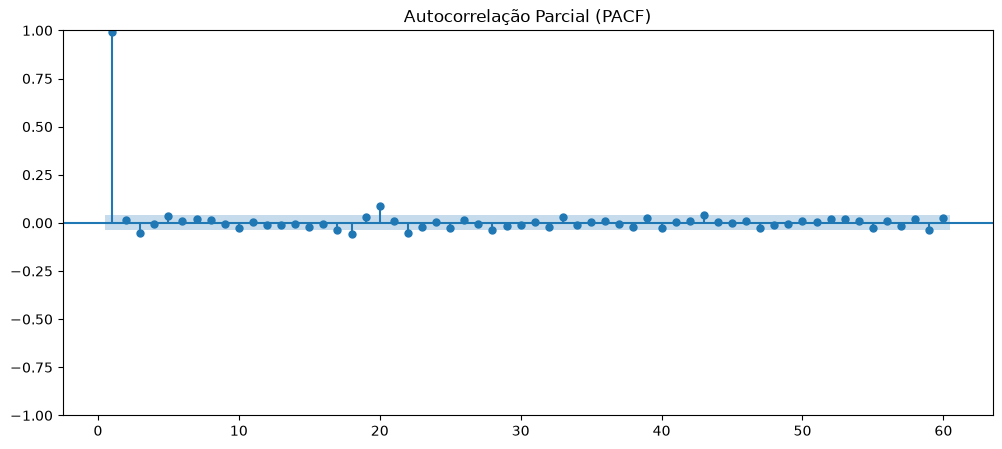


AUTOCORRELAÇÃO DOS RETORNOS

Os retornos diários costumam ser mais estacionários do que os preços.

Se poucas barras permanecerem significativas,
isso indica que grande parte da dependência temporal foi removida.



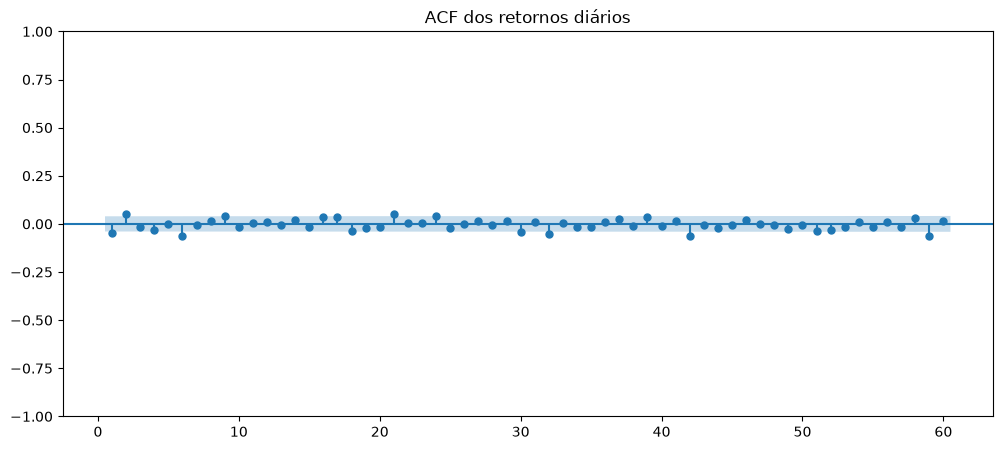

In [9]:
# ==============================================================================
# Série temporal
# ==============================================================================

serie = tb_analitica["close"].dropna()

# ==============================================================================
# Estatísticas descritivas
# ==============================================================================

print("=" * 80)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 80)
print(
    """
Resumo estatístico da variável de fechamento.
Permite identificar faixa de valores, dispersão e possíveis valores extremos.
"""
)

print(serie.describe())

# ==============================================================================
# Teste de estacionariedade
# ==============================================================================

print("\n" + "=" * 80)
print("TESTE DE DICKEY-FULLER AUMENTADO (ADF)")
print("=" * 80)
print(
    """
O teste ADF verifica se a série é estacionária.

Hipótese nula (H0): a série NÃO é estacionária.
Hipótese alternativa (H1): a série é estacionária.

Se p-value < 0.05:
    rejeita-se H0 e considera-se a série estacionária.
"""
)

resultado = adfuller(serie)

print(f"ADF Statistic : {resultado[0]:.4f}")
print(f"p-value       : {resultado[1]:.6f}")

if resultado[1] < 0.05:
    print("\nResultado: Série estacionária.")
else:
    print("\nResultado: Série NÃO estacionária.")

# ==============================================================================
# Série histórica
# ==============================================================================

print("\n" + "=" * 80)
print("GRÁFICO DA SÉRIE TEMPORAL")
print("=" * 80)
print(
    """
Permite visualizar tendências, mudanças de regime e períodos de alta volatilidade.
Em séries de preços é esperado observar tendência ao longo do tempo.
"""
)

plt.figure(figsize=(15,5))

plt.plot(tb_analitica["date"], serie)

plt.title("Preço de fechamento")
plt.xlabel("Data")
plt.ylabel("Close")

plt.grid(True)

plt.show()

# ==============================================================================
# ACF
# ==============================================================================

print("\n" + "=" * 80)
print("FUNÇÃO DE AUTOCORRELAÇÃO (ACF)")
print("=" * 80)
print(
    """
A ACF mede a correlação entre a série atual e seus valores passados.

Quanto mais lentamente as barras diminuem,
maior é a dependência temporal da série.

Barras fora da região azul representam correlações estatisticamente significativas.
"""
)

fig, ax = plt.subplots(figsize=(12,5))

plot_acf(
    serie,
    lags=60,
    zero=False,
    ax=ax
)

plt.title("Autocorrelação (ACF)")

plt.show()

# ==============================================================================
# PACF
# ==============================================================================

print("\n" + "=" * 80)
print("FUNÇÃO DE AUTOCORRELAÇÃO PARCIAL (PACF)")
print("=" * 80)
print(
    """
A PACF mede a correlação direta entre uma observação e cada defasagem,
eliminando o efeito das defasagens intermediárias.

Ela ajuda a identificar quais lags possuem influência direta sobre a série.
"""
)

fig, ax = plt.subplots(figsize=(12,5))

plot_pacf(
    serie,
    lags=60,
    zero=False,
    method="ywm",
    ax=ax
)

plt.title("Autocorrelação Parcial (PACF)")

plt.show()

# ==============================================================================
# ACF dos retornos
# ==============================================================================

print("\n" + "=" * 80)
print("AUTOCORRELAÇÃO DOS RETORNOS")
print("=" * 80)
print(
    """
Os retornos diários costumam ser mais estacionários do que os preços.

Se poucas barras permanecerem significativas,
isso indica que grande parte da dependência temporal foi removida.
"""
)

retornos = serie.pct_change().dropna()

fig, ax = plt.subplots(figsize=(12,5))

plot_acf(
    retornos,
    lags=60,
    zero=False,
    ax=ax
)

plt.title("ACF dos retornos diários")

plt.show()

## Feature importance

MAE: 0.3478

Importância das features
------------------------------------------------------------
           Feature  Importance
0             ma20        0.45
1         bb_lower        0.41
2       rsi_wilder        0.03
3         bb_upper        0.02
4             macd        0.02
5             ipca        0.01
6             ma50        0.01
7   close_ibovespa        0.01
8            selic        0.01
9      macd_signal        0.00
10       month_cos        0.00
11    close_sp_500        0.00
12     close_dolar        0.00
13       month_sin        0.00
14          volume        0.00
15     weekday_cos        0.00
16     weekday_sin        0.00


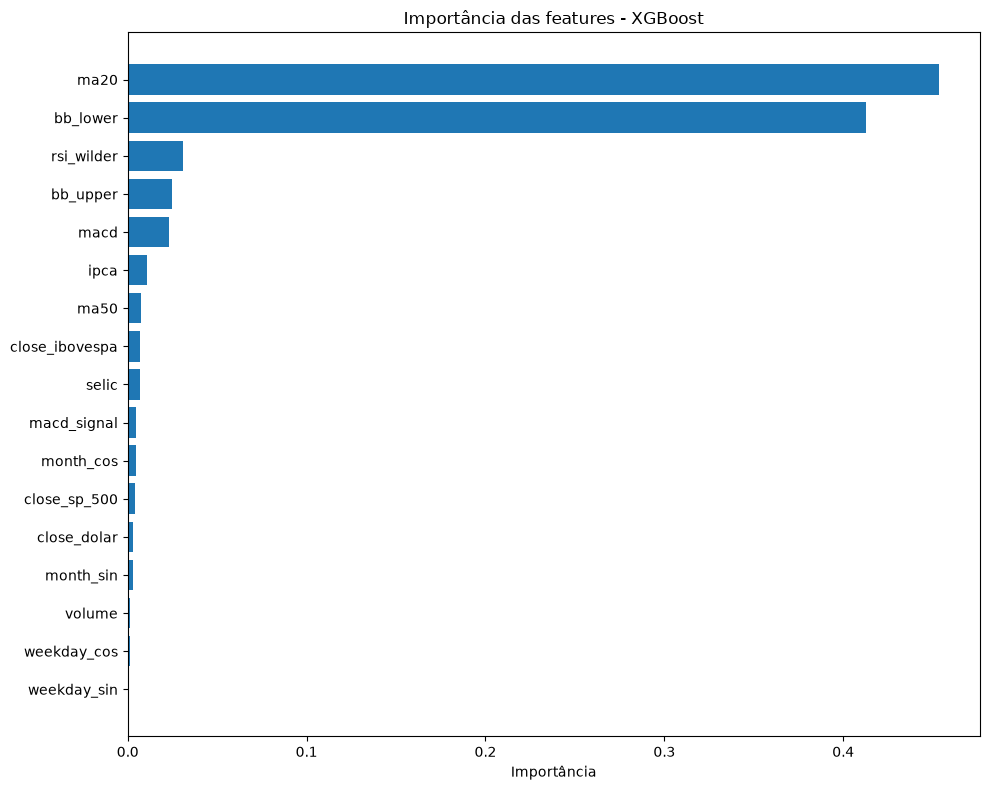

In [12]:
# ------------------------------------------------------------------------------
# Target = fechamento do próximo dia
# ------------------------------------------------------------------------------

df_model = tb_analitica.copy()

df_model["target"] = df_model["close"].shift(-1)

df_model = df_model.dropna().reset_index(drop=True)

# ------------------------------------------------------------------------------
# Features
# ------------------------------------------------------------------------------

features = [
    # "high",
    # "low",
    # "open",
    "volume",
    "close_dolar",
    "close_ibovespa",
    "close_sp_500",
    "selic",
    "ipca",
    "ma20",
    "ma50",
    "bb_upper",
    "bb_lower",
    "rsi_wilder",
    "macd",
    "macd_signal",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
]

X = df_model[features]
y = df_model["target"]

# ------------------------------------------------------------------------------
# Split temporal
# ------------------------------------------------------------------------------

split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# ------------------------------------------------------------------------------
# Modelo
# ------------------------------------------------------------------------------

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------------------------------------------------
# Avaliação
# ------------------------------------------------------------------------------

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)

print(f"MAE: {mae:.4f}")

# ------------------------------------------------------------------------------
# Importância das variáveis
# ------------------------------------------------------------------------------

importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("\nImportância das features")
print("-" * 60)
print(importance)

# ------------------------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importância")
plt.title("Importância das features - XGBoost")

plt.tight_layout()
plt.show()

SHAP - SHAPLEY ADDITIVE EXPLANATIONS

O SHAP mede a contribuição de cada variável para as previsões do modelo.

Quanto maior o valor absoluto de SHAP, maior a influência daquela variável.

No gráfico summary:
- As variáveis são ordenadas por importância.
- Vermelho representa valores altos da variável.
- Azul representa valores baixos.
- Quanto mais espalhados os pontos horizontalmente,
  maior é o impacto daquela variável na previsão.



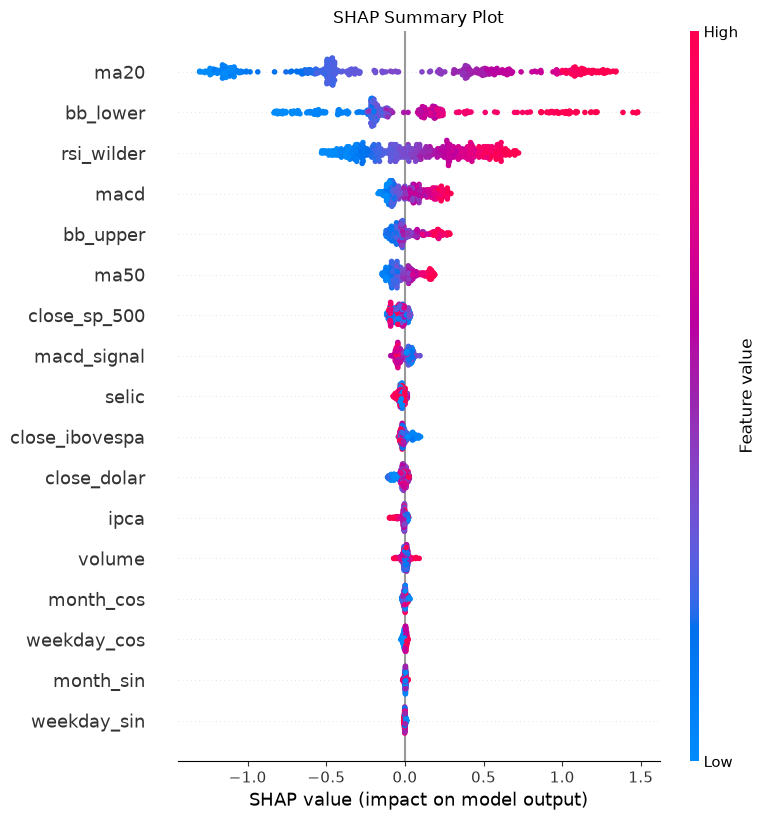


IMPORTÂNCIA GLOBAL DAS VARIÁVEIS

Este gráfico resume a importância média de cada variável,
considerando o valor absoluto dos SHAP values.

Quanto maior a barra, maior a contribuição média da variável
nas previsões do modelo.



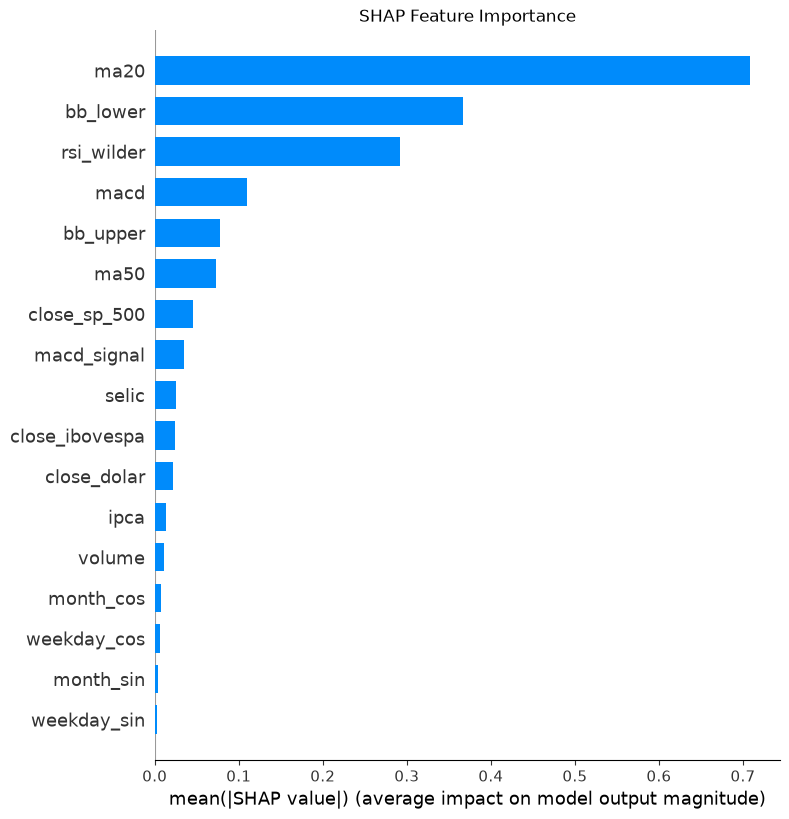

In [ ]:
# ==============================================================================
# SHAP
# ==============================================================================

print("=" * 80)
print("SHAP - SHAPLEY ADDITIVE EXPLANATIONS")
print("=" * 80)
print(
    """
O SHAP mede a contribuição de cada variável para as previsões do modelo.

Quanto maior o valor absoluto de SHAP, maior a influência daquela variável.

No gráfico summary:
- As variáveis são ordenadas por importância.
- Vermelho representa valores altos da variável.
- Azul representa valores baixos.
- Quanto mais espalhados os pontos horizontalmente,
  maior é o impacto daquela variável na previsão.
"""
)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

# ==============================================================================
# Summary Plot
# ==============================================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    show=False
)

plt.title("SHAP Summary Plot")

plt.tight_layout()

plt.show()

# ==============================================================================
# Feature Importance
# ==============================================================================

print("\n" + "=" * 80)
print("IMPORTÂNCIA GLOBAL DAS VARIÁVEIS")
print("=" * 80)
print(
    """
Este gráfico resume a importância média de cada variável,
considerando o valor absoluto dos SHAP values.

Quanto maior a barra, maior a contribuição média da variável
nas previsões do modelo.
"""
)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance")

plt.tight_layout()

plt.show()